In [1]:
# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

# numpy: the foundation of numerical computing in Python
# used for array operations, reshaping images, math calculations
import numpy as np

# pandas: used for reading and manipulating the CSV dataset
# think of it like Excel but in Python
import pandas as pd

# matplotlib: used for visualizing images, graphs, and results
# pyplot is the specific module for creating plots
import matplotlib.pyplot as plt

# tensorflow: the main deep learning framework made by Google
# everything we build runs on tensorflow under the hood
import tensorflow as tf

# keras: a high-level, beginner-friendly API built on top of tensorflow
# it simplifies building neural networks with readable code
from tensorflow import keras

# Sequential: lets us build the model layer by layer, in order
# like stacking lego blocks on top of each other
from keras.models import Sequential

# the building blocks of our CNN:
# Conv2D          → scans images to detect features (edges, shapes)
# MaxPooling2D    → shrinks the image while keeping important info
# Dense           → fully connected layer for final classification
# Activation      → adds non-linearity (e.g. relu, softmax)
# Dropout         → randomly disables neurons to prevent overfitting
# Flatten         → converts 2D image data into a 1D list for Dense layers
# BatchNormalization → keeps values stable and speeds up training
from keras.layers import (Conv2D, MaxPooling2D, Dense,
                          Activation, Dropout, Flatten, BatchNormalization)

# ImageDataGenerator: used to artificially expand your dataset
# by randomly flipping, rotating, zooming images during training
# helps the model generalize better to new faces
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# train_test_split: splits our data into two groups
# training set (model learns from this) and test set (we evaluate on this)
# the model NEVER sees the test set during training
from sklearn.model_selection import train_test_split

2026-03-05 13:19:46.566074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772716786.748860      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772716786.799938      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772716787.237751      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772716787.237789      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772716787.237792      24 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================================
# STEP 3: LOAD & EXPLORE THE DATASET (folder version)
# ============================================================

import os

# define the paths to train and test folders
# kaggle datasets are always found under /kaggle/input/
TRAIN_DIR = '/kaggle/input/datasets/msambare/fer2013/test'
TEST_DIR  = '/kaggle/input/datasets/msambare/fer2013/test'

# ============================================================
# check what emotion folders exist inside train
# each subfolder name IS the emotion label
# e.g. /train/happy/ contains all happy face images
# ============================================================
emotion_folders = sorted(os.listdir(TRAIN_DIR))
print("Emotion classes found:", emotion_folders)
print("Total classes:", len(emotion_folders))

Emotion classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total classes: 7


In [3]:
# this prints a heading so the output is easy to read
# \n adds a blank line before it
print("\nImage counts per emotion (Training set):")

# create an empty dictionary to store our results
# a dictionary holds key-value pairs, like: {"happy": 7215, "sad": 4830}
# we'll fill it in the loop below
counts = {}

# loop through each emotion folder one at a time
# emotion_folders = ['angry', 'disgust', 'fear', 'happy', ...]
# each time the loop runs, 'emotion' = one folder name e.g. "happy"
for emotion in emotion_folders:

    # build the full path to that emotion's folder
    # os.path.join safely combines folder paths for any operating system
    # e.g. '/kaggle/input/fer2013/train' + 'happy'
    #    = '/kaggle/input/fer2013/train/happy'
    folder_path = os.path.join(TRAIN_DIR, emotion)

    # os.listdir() returns a list of every file inside that folder
    # e.g. ['img1.jpg', 'img2.jpg', 'img3.jpg', ...]
    # len() counts how many files are in that list = number of images
    num_images = len(os.listdir(folder_path))

    # store the result in our dictionary
    # key   = emotion name  e.g. "happy"
    # value = image count   e.g. 7215
    # after the loop: counts = {"angry": 3995, "happy": 7215, ...}
    counts[emotion] = num_images

    # print one line per emotion
    # :10s means "pad the emotion name to 10 characters wide" so columns line up neatly
    # e.g.   "angry      → 3995 images"
    #        "happy      → 7215 images"
    print(f"  {emotion:10s} → {num_images} images")

# after the loop is done, add up ALL values in the dictionary
# sum(counts.values()) = 3995 + 436 + 4097 + 7215 + ...
# gives us the total number of training images across all emotions
print("\nTotal training images:", sum(counts.values()))


Image counts per emotion (Training set):
  angry      → 958 images
  disgust    → 111 images
  fear       → 1024 images
  happy      → 1774 images
  neutral    → 1233 images
  sad        → 1247 images
  surprise   → 831 images

Total training images: 7178


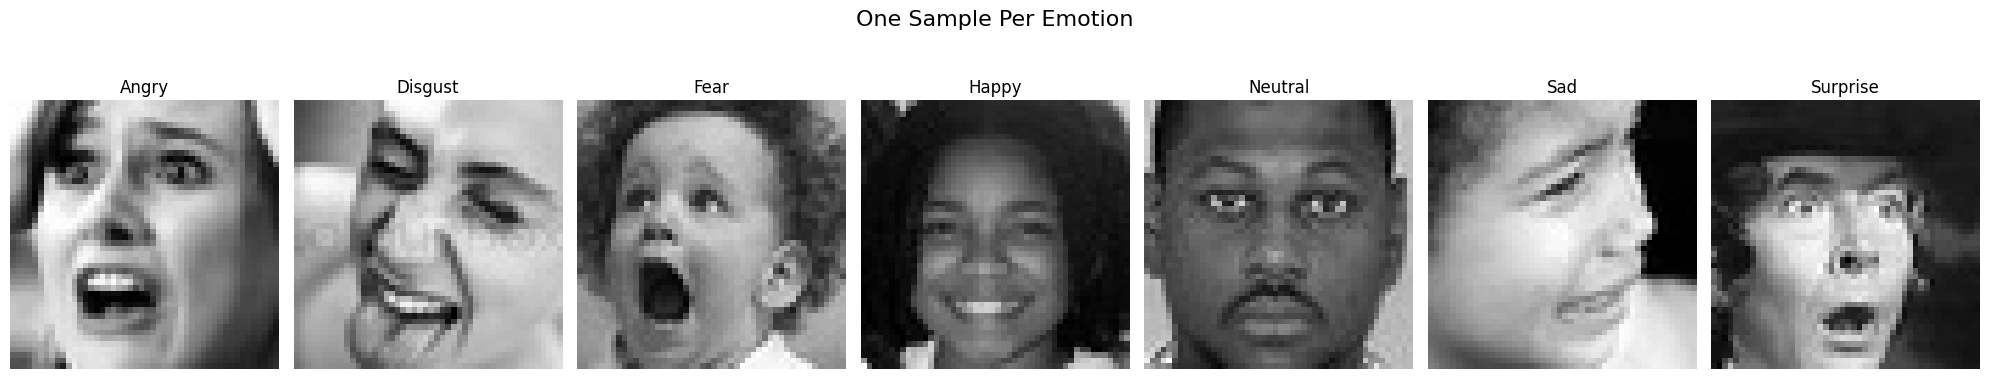

In [4]:
# ============================================================
# STEP 4: VISUALIZE SAMPLE IMAGES FROM THE DATASET
# ============================================================

# we always visualize data before training
# reason: confirms images loaded correctly, helps you understand
# what the model will actually be learning from

import matplotlib.image as mpimg

# ============================================================
# 4A. show one sample image from EACH emotion
# ============================================================

# how many emotions we have
num_emotions = len(emotion_folders)

# create a figure with 1 row and 7 columns (one column per emotion)
# figsize=(20, 4) makes it wide enough to fit all 7 side by side
fig, axes = plt.subplots(1, num_emotions, figsize=(20, 4))

# loop through each emotion and its corresponding plot slot
# enumerate gives us both the index (i) and the value (emotion)
# i     = 0, 1, 2, 3, 4, 5, 6
# emotion = 'angry', 'disgust', 'fear', ...
for i, emotion in enumerate(emotion_folders):

    # build path to this emotion's folder
    folder_path = os.path.join(TRAIN_DIR, emotion)

    # pick the very first image in the folder
    first_image_name = os.listdir(folder_path)[0]

    # build the full path to that image file
    image_path = os.path.join(folder_path, first_image_name)

    # read the image from disk into a numpy array
    # the array contains pixel values e.g. [[120, 45, 200], [80, 90, 110]...]
    img = mpimg.imread(image_path)

    # display the image in the correct subplot slot
    # cmap='gray' renders it as a grayscale image (black & white)
    axes[i].imshow(img, cmap='gray')

    # set the title below each image to the emotion name
    # .capitalize() makes first letter uppercase e.g. 'happy' → 'Happy'
    axes[i].set_title(emotion.capitalize(), fontsize=12)

    # remove the x and y axis ticks — they add no value for images
    axes[i].axis('off')

plt.suptitle('One Sample Per Emotion', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

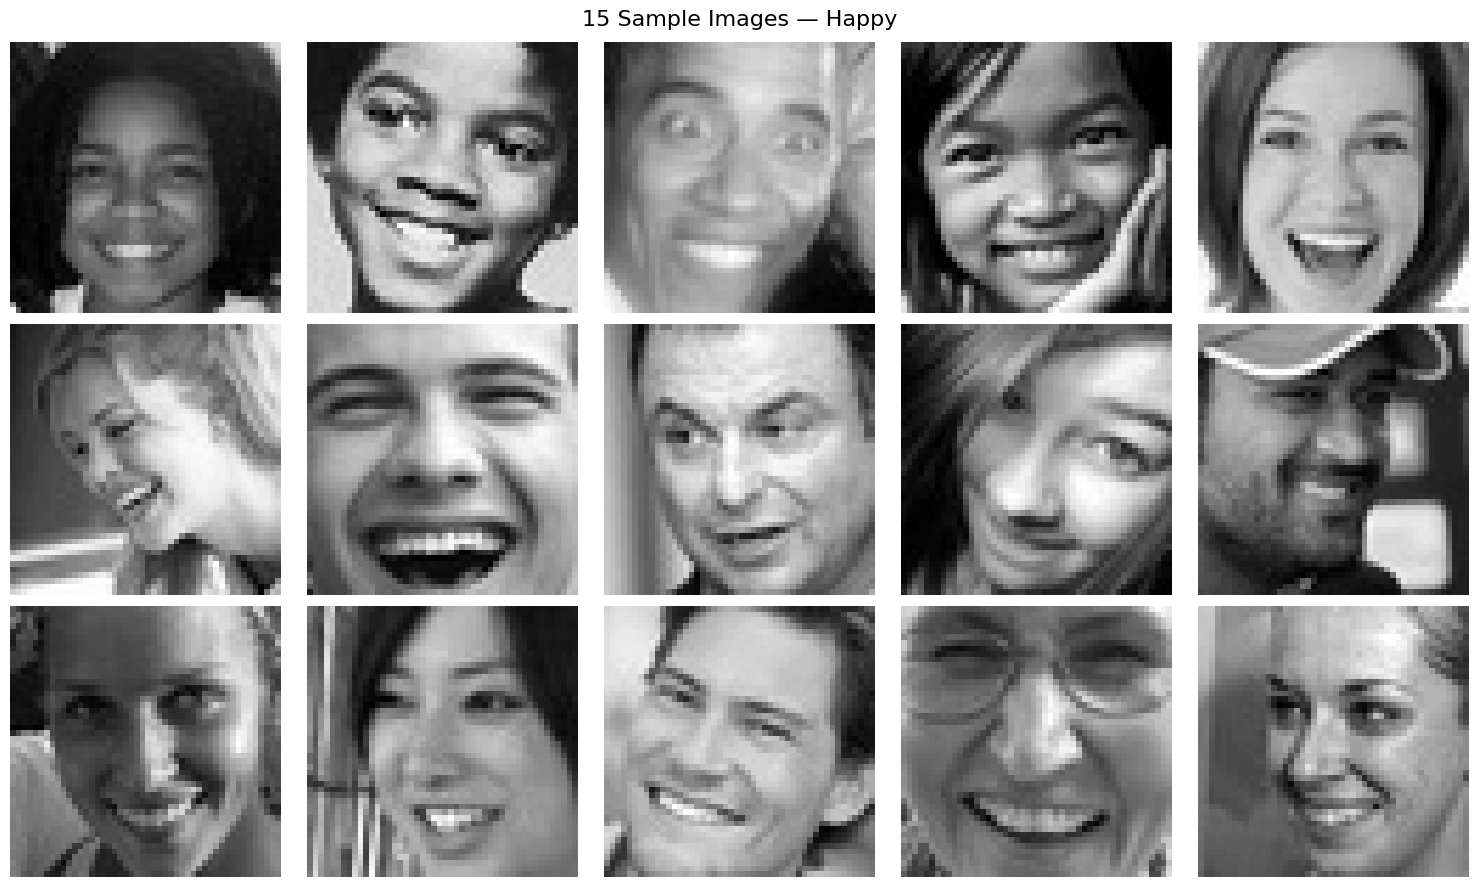

In [5]:
# ============================================================
# 4B. show multiple samples of the SAME emotion in a grid
# this helps you see how varied the images are within one class
# e.g. "happy" faces can look very different from each other
# ============================================================

emotion_to_explore = 'happy'   # ← change this to any emotion you want

folder_path  = os.path.join(TRAIN_DIR, emotion_to_explore)
image_files  = os.listdir(folder_path)

# show a 3x5 grid = 15 sample images from this emotion
rows, cols = 3, 5

fig, axes = plt.subplots(rows, cols, figsize=(15, 9))

# axes.flat lets us loop through all subplots as a single flat list
# instead of a 2D grid, making it easier to fill one by one
for i, ax in enumerate(axes.flat):

    # load the i-th image from this emotion folder
    img_path = os.path.join(folder_path, image_files[i])
    img      = mpimg.imread(img_path)

    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle(f'15 Sample Images — {emotion_to_explore.capitalize()}', 
             fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 4C. check the image dimensions
# this is critical — our model expects exactly (48, 48) images
# if the size is different, we'll need to resize in the next step
# ============================================================

# check dimensions of one image from each emotion
print("Image dimensions per emotion:")
print("-" * 35)

for emotion in emotion_folders:
    folder_path      = os.path.join(TRAIN_DIR, emotion)
    sample_img_path  = os.path.join(folder_path, os.listdir(folder_path)[0])
    img              = mpimg.imread(sample_img_path)

    # img.shape returns (height, width) for grayscale
    # or (height, width, channels) for color images
    print(f"  {emotion:10s} → shape: {img.shape}")

Image dimensions per emotion:
-----------------------------------
  angry      → shape: (48, 48)
  disgust    → shape: (48, 48)
  fear       → shape: (48, 48)
  happy      → shape: (48, 48)
  neutral    → shape: (48, 48)
  sad        → shape: (48, 48)
  surprise   → shape: (48, 48)
